<a href="https://colab.research.google.com/github/yxmauw/eye-disease-classification/blob/main/UNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setting up local directory to work
Stream data direct from kaggle using Kaggle API

In [ ]:
# install kaggle API
# !pip install kaggle

In [1]:
!git clone https://github.com/yxmauw/eye-disease-classification.git

Cloning into 'eye-disease-classification'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 90 (delta 47), reused 0 (delta 0), pack-reused 0
Unpacking objects: 100% (90/90), done.


In [2]:
!mkdir ~/.kaggle #Make a directory named “.kaggle”

In [3]:
!cp ./eye-disease-classification/kaggle.json ~/.kaggle/ # Copy the “kaggle.json” into this new directory

In [4]:
!chmod 600 ~/.kaggle/kaggle.json # Allocate the required permission for this file

In [5]:
!kaggle datasets download gunavenkatdoddi/eye-diseases-classification # download dataset

 99% 729M/736M [00:06<00:00, 143MB/s]
100% 736M/736M [00:06<00:00, 115MB/s]


In [6]:
! unzip eye-diseases-classification.zip

Archive:  eye-diseases-classification.zip
  inflating: dataset/cataract/0_left.jpg  
  inflating: dataset/cataract/103_left.jpg  
  inflating: dataset/cataract/1062_right.jpg  
  inflating: dataset/cataract/1083_left.jpg  
  inflating: dataset/cataract/1084_right.jpg  
  inflating: dataset/cataract/1102_left.jpg  
  inflating: dataset/cataract/1102_right.jpg  
  inflating: dataset/cataract/1115_left.jpg  
  inflating: dataset/cataract/1126_right.jpg  
  inflating: dataset/cataract/112_right.jpg  
  inflating: dataset/cataract/1144_left.jpg  
  inflating: dataset/cataract/1144_right.jpg  
  inflating: dataset/cataract/1164_left.jpg  
  inflating: dataset/cataract/1167_right.jpg  
  inflating: dataset/cataract/119_left.jpg  
  inflating: dataset/cataract/1285_left.jpg  
  inflating: dataset/cataract/1415_left.jpg  
  inflating: dataset/cataract/1415_right.jpg  
  inflating: dataset/cataract/1435_left.jpg  
  inflating: dataset/cataract/1444_left.jpg  
  inflating: dataset/cataract/1452_l

## Explore images

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
%config InlineBackend.figure_format = 'retina'

### Number of images in dataset:

In [8]:
import fnmatch
import os

# image files count
cataract_count = len(fnmatch.filter(os.listdir('./dataset/cataract'), '*.jpg'))
dre_count = len(fnmatch.filter(os.listdir('./dataset/diabetic_retinopathy'), '*.jpeg'))
glaucoma_count = len(fnmatch.filter(os.listdir('./dataset/glaucoma'), '*.jpg'))
normal_count = len(fnmatch.filter(os.listdir('./dataset/normal'), '*.jpg'))
total_image_count = cataract_count + dre_count + \
                    glaucoma_count + normal_count
# print count
print('---Categories---')
print('Cataract:', cataract_count)
print('Diabetic retinopathy:', dre_count)
print('Glaucoma:', glaucoma_count)
print('Normal', normal_count)
print()
print('---Total image count---')
print(total_image_count)

---Categories---
Cataract: 938
Diabetic retinopathy: 1098
Glaucoma: 906
Normal 1074

---Total image count---
4016


### Image dimensions, properties:

In [9]:
# load example image
from PIL import Image 
im = Image.open('./dataset/glaucoma/1495_left.jpg')
# summarize some details about the image
print(im.format)
print(im.mode)
print(im.size) # size already 512 x 512

pixels = np.asarray(im)
print(pixels[0])
print(pixels.shape) # 3 channel last

JPEG
RGB
(512, 512)
[[0 0 0]
 [0 0 0]
 [0 0 0]
 ...
 [0 0 0]
 [0 0 0]
 [0 0 0]]
(512, 512, 3)


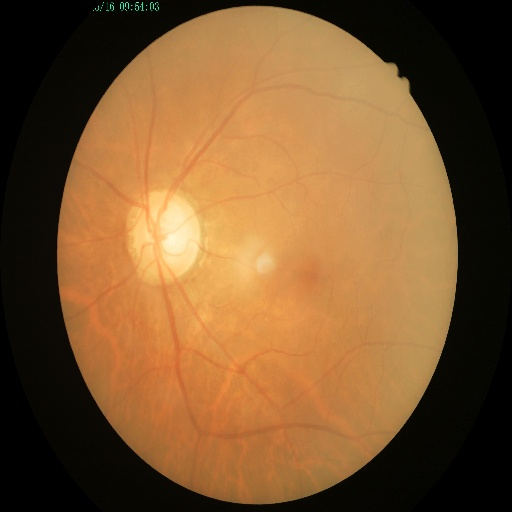

In [ ]:
#Import library
from IPython import display
display.Image(filename='./dataset/glaucoma/1495_left.jpg', width=200, height=150)

In [10]:
# calculate image pixel mean, min, max

mean = pixels.mean()
print('Mean: %.3f' % mean)
# confirm pixel range is 0-255
print('Min: %.3f, Max: %.3f' % (pixels.min(), pixels.max()))

Mean: 86.173
Min: 0.000, Max: 255.000


## Visualise preprocessed images

In [11]:
import tensorflow as tf
from tensorflow.keras import layers
print(tf.__version__) #2.8.2

2.8.2


What happens after resizing and rescaling: 

In [12]:
resize_and_rescale = tf.keras.Sequential([   
    layers.Resizing(160,160) ,  # needs to be symmetrical
    layers.Rescaling(1./255) # desired height, width in model pipeline
])

result = resize_and_rescale(pixels)
print(result.shape) # new shape, channels

(160, 160, 3)


What happens to image pixel values after rescaling:

In [13]:
print("Min and max pixel values:", result.numpy().min(), result.numpy().max())

Min and max pixel values: 0.0 1.0


Show images before and after preprocessing:

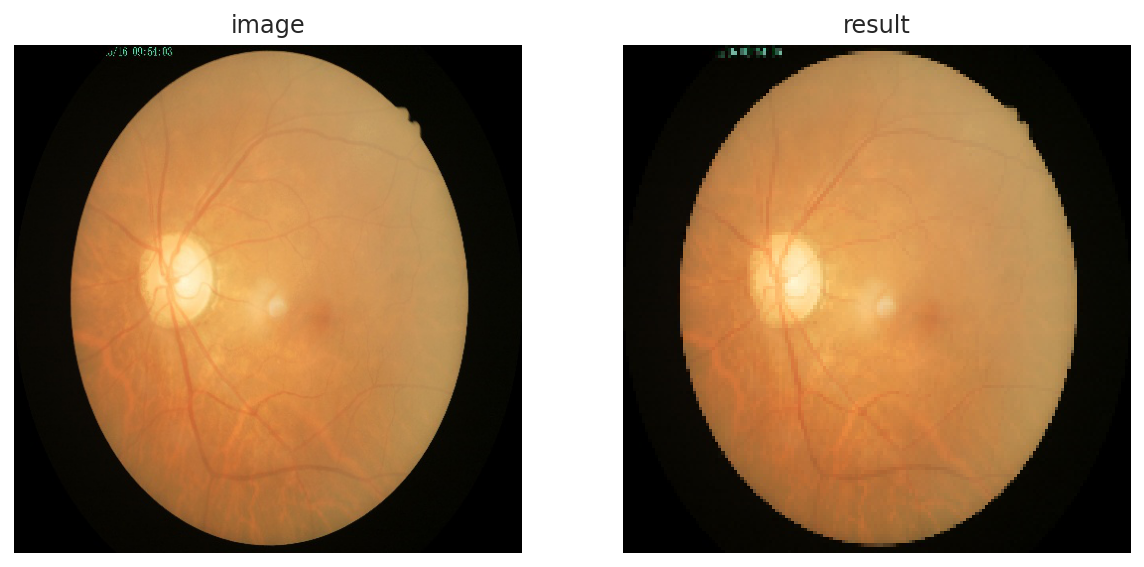

In [14]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10,8))
ax0.imshow(im)
ax0.axis('off')
ax0.set_title('image')
# after pixel normalisation
ax1.imshow(result)
ax1.axis('off')
ax1.set_title('result')
plt.show() # result seems to have slight blurring of image, but still good definition

## Create train and validation datasets

In [15]:
# generate dataset that can be used for machine learning
from tensorflow.keras.utils import image_dataset_from_directory

image_size = (160, 160) # very important to get this right, will determine model success
batch_size = 32

train_ds = image_dataset_from_directory(
    './dataset/',
    image_size=image_size,
    shuffle=True,
    seed=1,
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    label_mode='categorical'
)

val_ds = image_dataset_from_directory(
    './dataset/',
    image_size=image_size,
    shuffle=True,
    seed=1,
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    label_mode='categorical'
)

Found 4217 files belonging to 4 classes.
Using 3374 files for training.
Found 4217 files belonging to 4 classes.
Using 843 files for validation.


### Visualise images and labels together

['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


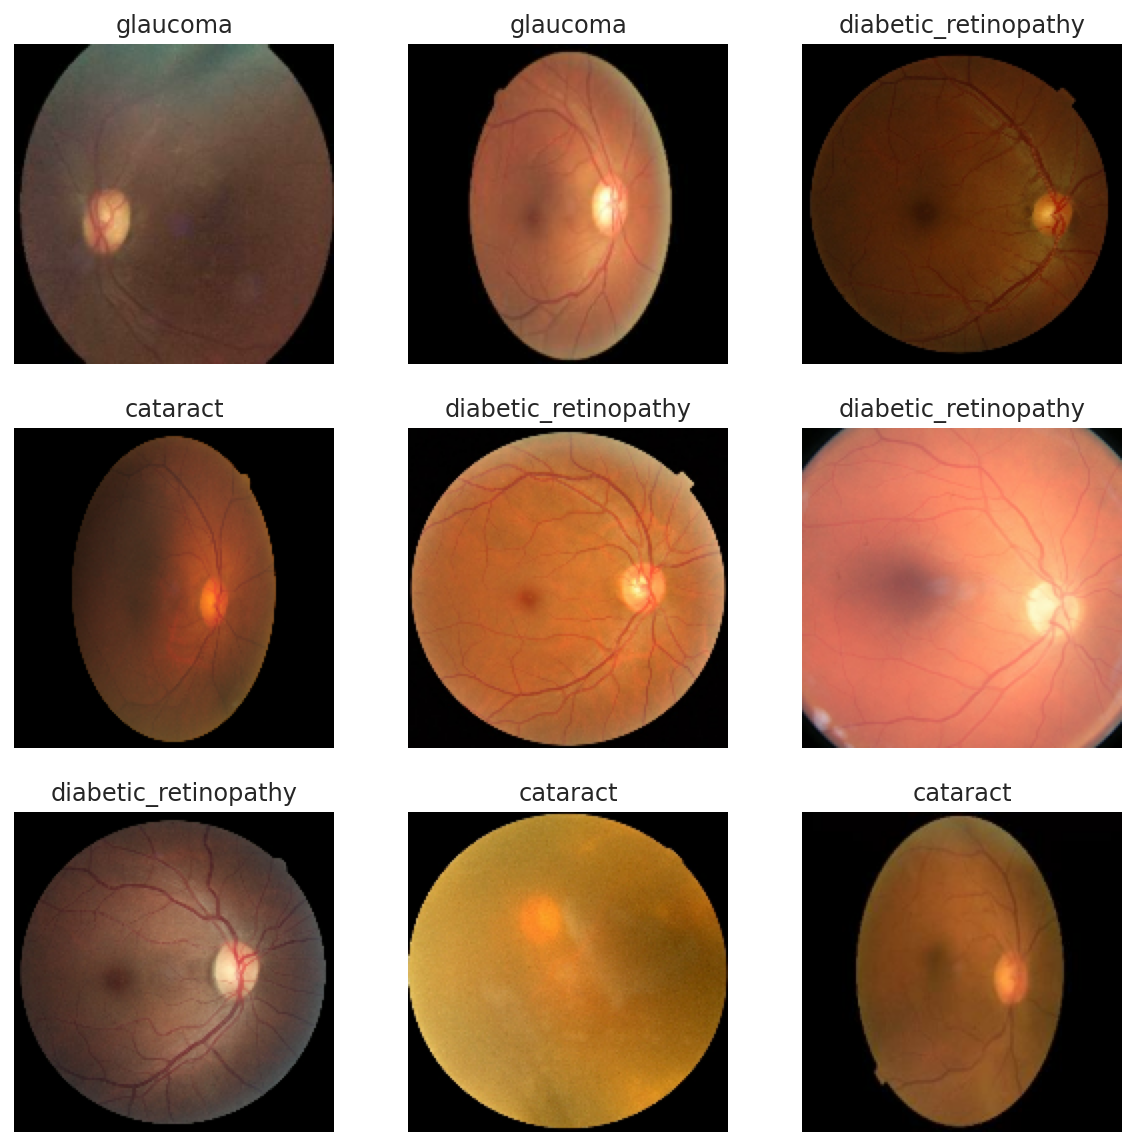

In [16]:
# preview of how images are labelled
class_names = train_ds.class_names
print(class_names)

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): # each image 160 x 160
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[tf.argmax(labels[i], axis=0)])
    plt.axis("off")

## Configure datasets for optimal performance

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

## Data augmentation

In [21]:
data_augmentation = tf.keras.Sequential(
    [ layers.RandomFlip("horizontal_and_vertical", seed=1), 
      layers.RandomRotation(0.2, seed=2),
      layers.RandomContrast(0.2, seed=1)
    ])

### Visualise augmented images

In [22]:
def augmented_img():
  for image, _ in train_ds.take(1):  # take a sample image from training set
    plt.figure(figsize=(8, 8))
    first_image = image[0]
    for i in range(9):
      ax = plt.subplot(3, 3, i + 1)
      augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
      plt.imshow(augmented_image[0] / 255) # rescale pixel 0 to 1
      plt.axis("off")

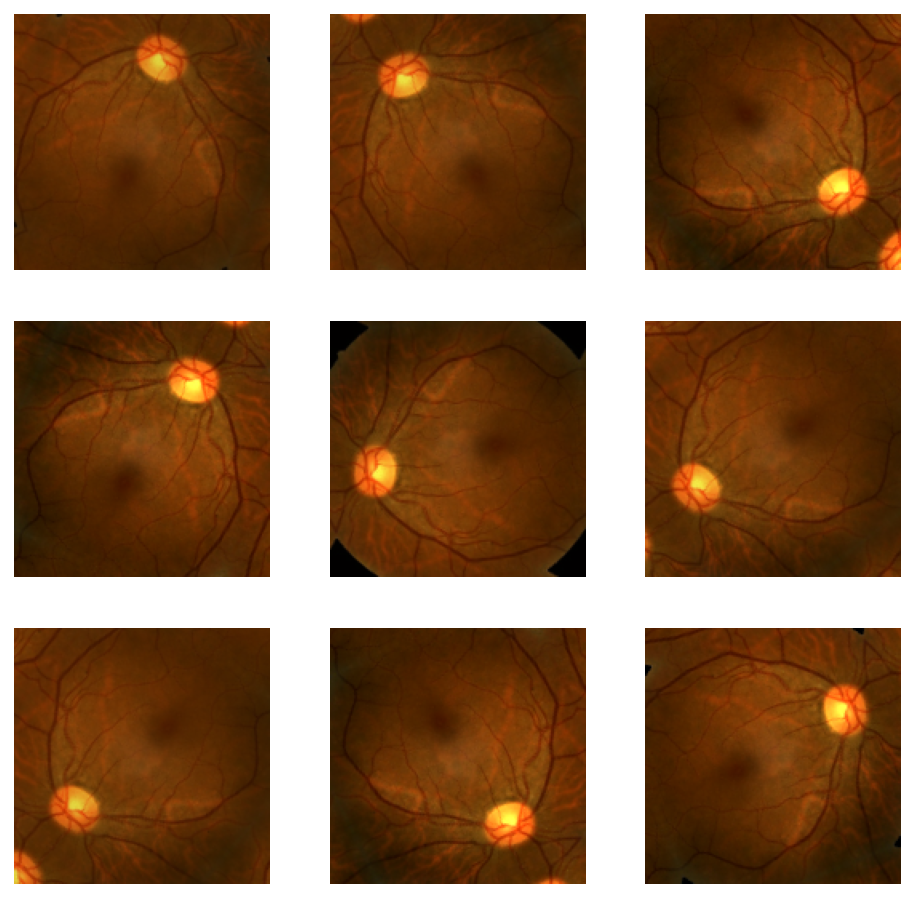

In [23]:
augmented_img()

## Create Base UNet model

[UNet code architecture](https://blog.paperspace.com/unet-architecture-image-segmentation/)

<img src="https://miro.medium.com/max/1020/1*_azTISV4DteZd8hCSiQ7Dg.png" alt="UNet model" width="500" height="300">


In [24]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, ReLU
from tensorflow.keras.layers import BatchNormalization, Conv2DTranspose, Concatenate
from tensorflow.keras.models import Model, Sequential

In [25]:
def convolution_operation(entered_input, filters=64):
    # Taking first input and implementing the first conv block
    conv1 = Conv2D(filters, kernel_size = (3,3), padding = "same")(entered_input)
    batch_norm1 = BatchNormalization()(conv1)
    act1 = ReLU()(batch_norm1)
    
    # Taking first input and implementing the second conv block
    conv2 = Conv2D(filters, kernel_size = (3,3), padding = "same")(act1)
    batch_norm2 = BatchNormalization()(conv2)
    act2 = ReLU()(batch_norm2)
    
    return act2

In [26]:
def encoder(entered_input, filters=64):
    # Collect the start and end of each sub-block for normal pass and skip connections
    enc1 = convolution_operation(entered_input, filters)
    MaxPool1 = MaxPooling2D(strides = (2,2))(enc1)
    return enc1, MaxPool1

In [27]:
def decoder(entered_input, skip, filters=64):
    # Upsampling and concatenating the essential features
    Upsample = Conv2DTranspose(filters, (2, 2), strides=2, padding="same")(entered_input)
    Connect_Skip = Concatenate()([Upsample, skip])
    out = convolution_operation(Connect_Skip, filters)
    return out

In [28]:
def U_Net(Image_Size): # without data augmentation
    # Take the image size and shape
    input1 = tf.keras.Input(Image_Size)
    # rescale
    input1 = layers.Rescaling(1./255)(input1)

    # Construct the encoder blocks
    skip1, encoder_1 = encoder(input1, 64)
    skip2, encoder_2 = encoder(encoder_1, 64*2)
    skip3, encoder_3 = encoder(encoder_2, 64*4)
    skip4, encoder_4 = encoder(encoder_3, 64*8)
    
    # Preparing the next block
    conv_block = convolution_operation(encoder_4, 64*16)
    
    # Construct the decoder blocks
    decoder_1 = decoder(conv_block, skip4, 64*8)
    decoder_2 = decoder(decoder_1, skip3, 64*4)
    decoder_3 = decoder(decoder_2, skip2, 64*2)
    decoder_4 = decoder(decoder_3, skip1, 64)
    
    out_1 = Conv2D(4, 1, padding="same", activation="relu")(decoder_4)
    #final layers to force shape to suit binary label shapes
    flat = tf.keras.layers.Flatten()(out_1)
    out_2 = tf.keras.layers.Dense(4, activation='softmax')(flat)

    model = Model(input1, out_2)
    return model

In [29]:
input_shape = (160, 160, 3)
model = U_Net(input_shape)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 160, 160, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 160, 160, 64  1792        ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 160, 160, 64  256        ['conv2d[1][0]']                 
 alization)                     )                                                             

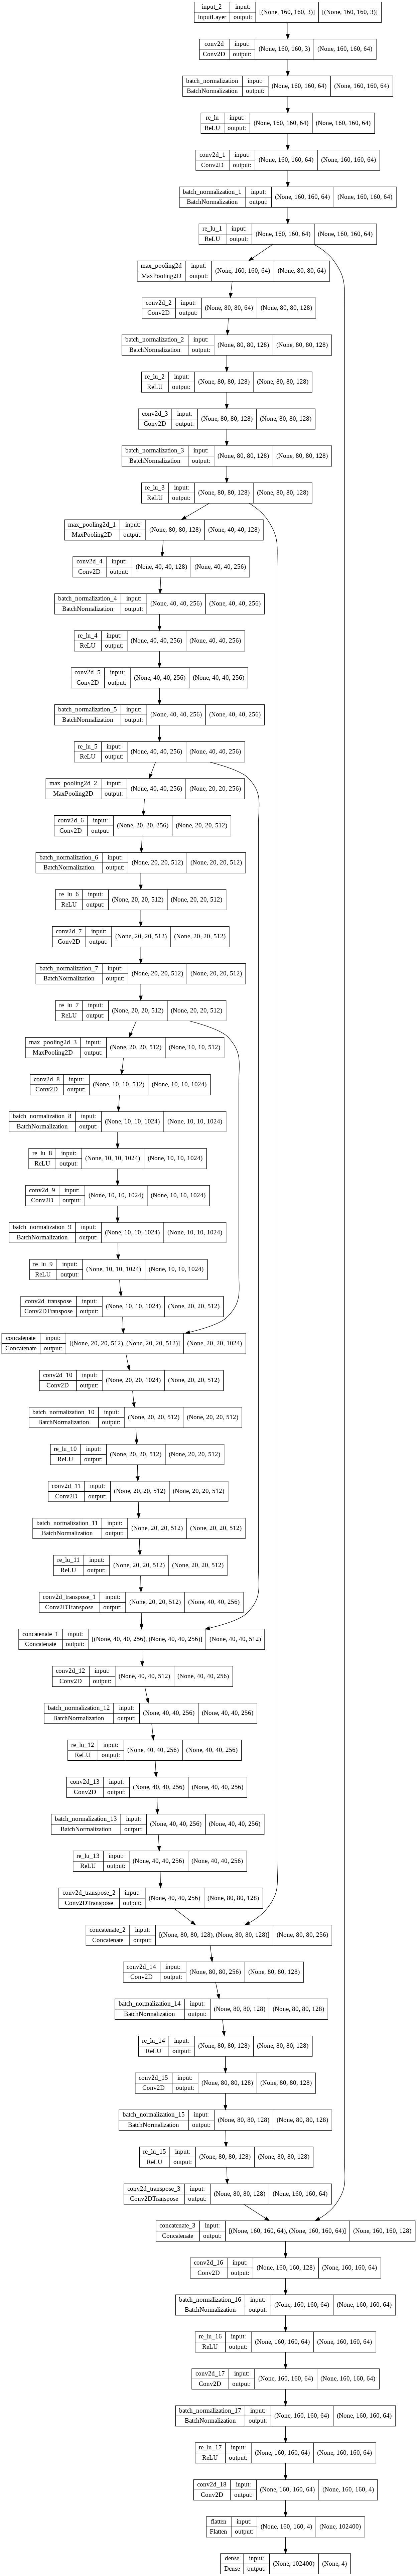

In [ ]:
# show model in graph manner
tf.keras.utils.plot_model(model, to_file = "Model.png", show_shapes=True)

## Compile, fit model, run

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

In [30]:
model.compile(optimizer='adam', # try SGD next
              loss="categorical_crossentropy", # match label_mode='categorical'
              metrics=['accuracy','AUC'])

# Train the model, doing validation at the end of each epoch.
epochs = 15 # experience shows early stopping by epoch 14

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("drive/MyDrive/Colab Notebooks/UNet_ep{epoch}_val{val_loss:.3f}", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=3,min_delta=0.001,restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('drive/MyDrive/Colab Notebooks/history.csv')
]

history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/5
106/106 [==============================] - 1016s 10s/step - loss: 2.1207 - accuracy: 0.5412 - auc: 0.7955 - val_loss: 1.4332 - val_accuracy: 0.3310 - val_auc: 0.6191
Epoch 2/5
106/106 [==============================] - 1068s 10s/step - loss: 0.7160 - accuracy: 0.6734 - auc: 0.9055 - val_loss: 0.7237 - val_accuracy: 0.6880 - val_auc: 0.9073
Epoch 3/5
106/106 [==============================] - 1012s 10s/step - loss: 0.6530 - accuracy: 0.7104 - auc: 0.9222 - val_loss: 0.6268 - val_accuracy: 0.7224 - val_auc: 0.9281
Epoch 4/5
106/106 [==============================] - 954s 9s/step - loss: 0.5981 - accuracy: 0.7407 - auc: 0.9356 - val_loss: 0.6390 - val_accuracy: 0.7272 - val_auc: 0.9253
Epoch 5/5
106/106 [==============================] - 974s 9s/step - loss: 0.5164 - accuracy: 0.7795 - auc: 0.9524 - val_loss: 0.6147 - val_accuracy: 0.7473 - val_auc: 0.9357


## Run from saved model
after 5 epochs

In [31]:
# can delete this cell once above cell able to run for 15 epochs and early stop
model_epoch5 = tf.keras.models.load_model('drive/MyDrive/Colab Notebooks/UNet_ep5_val0.615')

# Continue training the model # 5 + 5
epochs = 5 

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("drive/MyDrive/Colab Notebooks/UNet2_ep{epoch}_val{val_loss:.3f}", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=3,min_delta=0.001,restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('drive/MyDrive/Colab Notebooks/history.csv', append=True)
]

history2 = model_epoch5.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/5
106/106 [==============================] - 1020s 10s/step - loss: 0.5817 - accuracy: 0.7667 - auc: 0.9433 - val_loss: 0.6255 - val_accuracy: 0.7592 - val_auc: 0.9320
Epoch 2/5
106/106 [==============================] - 1030s 10s/step - loss: 0.4098 - accuracy: 0.8435 - auc: 0.9703 - val_loss: 0.6128 - val_accuracy: 0.7343 - val_auc: 0.9361
Epoch 3/5
106/106 [==============================] - 958s 9s/step - loss: 0.2654 - accuracy: 0.8992 - auc: 0.9868 - val_loss: 0.6802 - val_accuracy: 0.7378 - val_auc: 0.9242
Epoch 4/5
106/106 [==============================] - 985s 9s/step - loss: 0.1750 - accuracy: 0.9345 - auc: 0.9943 - val_loss: 1.8829 - val_accuracy: 0.7200 - val_auc: 0.8817
Epoch 5/5
106/106 [==============================] - 1003s 9s/step - loss: 0.1107 - accuracy: 0.9612 - auc: 0.9975 - val_loss: 0.5594 - val_accuracy: 0.8149 - val_auc: 0.9557


In [40]:
# can delete this cell possible
# try another 5 epochs (total 15 epochs)
model_epoch10 = tf.keras.models.load_model('drive/MyDrive/Colab Notebooks/UNet2_ep5_val0.559')

# Continue training the model # 5 + 5
epochs = 5 

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("drive/MyDrive/Colab Notebooks/UNet3_ep{epoch}_val{val_loss:.3f}", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=3,min_delta=0.001,restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('drive/MyDrive/Colab Notebooks/history.csv', append=True)
]

history3 = model_epoch10.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/5
106/106 [==============================] - 964s 9s/step - loss: 0.1160 - accuracy: 0.9647 - auc: 0.9966 - val_loss: 0.7109 - val_accuracy: 0.7592 - val_auc: 0.9348
Epoch 2/5
106/106 [==============================] - 958s 9s/step - loss: 0.0789 - accuracy: 0.9745 - auc: 0.9987 - val_loss: 0.8802 - val_accuracy: 0.7402 - val_auc: 0.9103
Epoch 3/5
106/106 [==============================] - 948s 9s/step - loss: 0.1446 - accuracy: 0.9606 - auc: 0.9949 - val_loss: 1.4538 - val_accuracy: 0.2681 - val_auc: 0.4640
Epoch 4/5
106/106 [==============================] - 950s 9s/step - loss: 0.0558 - accuracy: 0.9825 - auc: 0.9994 - val_loss: 0.8679 - val_accuracy: 0.7295 - val_auc: 0.9086
Epoch 4: early stopping


After another 5 epochs (total 15), validation loss worsen. Best val loss was achieved at total 10 epochs.

## Learning Curves 

In [41]:
history = pd.read_csv('drive/MyDrive/Colab Notebooks/history.csv')
history.head(3)

,epoch,accuracy,auc,loss,val_accuracy,val_auc,val_loss
0,0,0.541197,0.795494,2.120675,0.330961,0.619089,1.433226
1,1,0.673385,0.905523,0.715998,0.688019,0.907314,0.723661
2,2,0.710433,0.922237,0.652981,0.722420,0.928079,0.626835


In [42]:
acc = history['accuracy']
val_acc = history['val_accuracy']

loss = history['loss']
val_loss = history['val_loss']

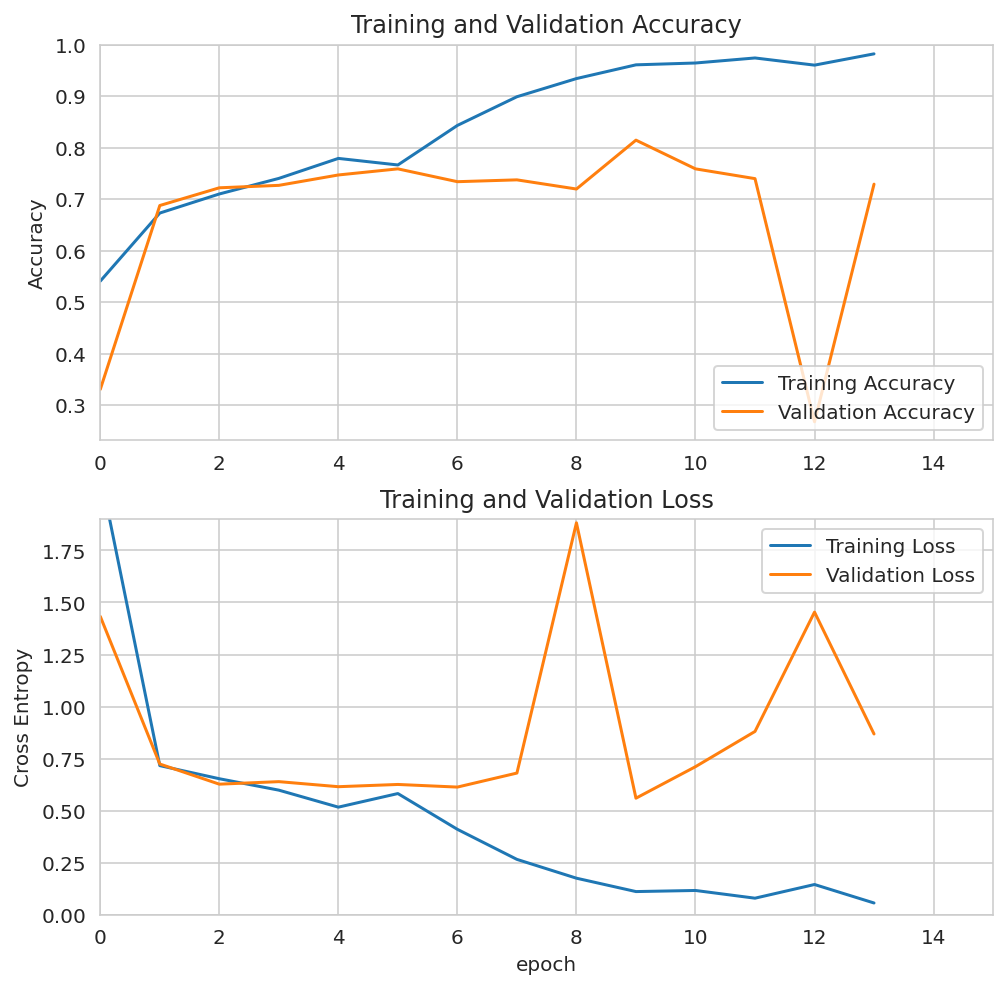

In [44]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.xlim([0,15])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.9])
plt.xlim([0,15])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

Looks like model at epoch 5 has the best generalisation, but sacrificing improvements in accuracy

## Model with augmentation layers

adding data augmentation layers

In [45]:
def U_Net_augmented(Image_Size):
    # Take the image size and shape
    input1 = tf.keras.Input(Image_Size)
    # data augmentation
    input1 = data_augmentation(input1)
    # rescale
    input1 = layers.Rescaling(1./255)(input1)

    # Construct the encoder blocks
    skip1, encoder_1 = encoder(input1, 64)
    skip2, encoder_2 = encoder(encoder_1, 64*2)
    skip3, encoder_3 = encoder(encoder_2, 64*4)
    skip4, encoder_4 = encoder(encoder_3, 64*8)
    
    # Preparing the next block
    conv_block = convolution_operation(encoder_4, 64*16)
    
    # Construct the decoder blocks
    decoder_1 = decoder(conv_block, skip4, 64*8)
    decoder_2 = decoder(decoder_1, skip3, 64*4)
    decoder_3 = decoder(decoder_2, skip2, 64*2)
    decoder_4 = decoder(decoder_3, skip1, 64)
    
    out_1 = Conv2D(4, 1, padding="same", activation="relu")(decoder_4)
    #final layers to force shape to suit binary label shapes
    flat = tf.keras.layers.Flatten()(out_1)
    out_2 = tf.keras.layers.Dense(4, activation='softmax')(flat)

    model = Model(input1, out_2)
    return model

In [46]:
input_shape = (160, 160, 3)
model = U_Net_augmented(input_shape)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 160, 160, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_19 (Conv2D)             (None, 160, 160, 64  1792        ['input_4[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization_18 (BatchN  (None, 160, 160, 64  256        ['conv2d_19[1][0]']              
 ormalization)                  )                                                           

## Compile, fit model, run

In [48]:
model.compile(optimizer='adam', 
              loss="categorical_crossentropy", # match label_mode='categorical'
              metrics=['accuracy','AUC'])

# Train the model, doing validation at the end of each epoch.
epochs = 10 # experience shows early stopping by epoch 10

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("drive/MyDrive/Colab Notebooks/UNet_augm_ep{epoch}_val{val_loss:.3f}", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=3,min_delta=0.001,restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('drive/MyDrive/Colab Notebooks/history_augm.csv') # save history
]

history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/5
106/106 [==============================] - 983s 9s/step - loss: 0.7671 - accuracy: 0.6761 - auc: 0.8978 - val_loss: 0.9789 - val_accuracy: 0.5718 - val_auc: 0.8381
Epoch 2/5
106/106 [==============================] - 968s 9s/step - loss: 0.6253 - accuracy: 0.7250 - auc: 0.9272 - val_loss: 0.9419 - val_accuracy: 0.5243 - val_auc: 0.8173
Epoch 3/5
106/106 [==============================] - 968s 9s/step - loss: 0.5938 - accuracy: 0.7377 - auc: 0.9347 - val_loss: 1.2141 - val_accuracy: 0.4508 - val_auc: 0.7284
Epoch 4/5
106/106 [==============================] - 957s 9s/step - loss: 0.5120 - accuracy: 0.7756 - auc: 0.9530 - val_loss: 1.3400 - val_accuracy: 0.3915 - val_auc: 0.6944
Epoch 5/5
106/106 [==============================] - 967s 9s/step - loss: 0.3854 - accuracy: 0.8456 - auc: 0.9736 - val_loss: 0.7250 - val_accuracy: 0.6572 - val_auc: 0.8977


In [49]:
# possibly can delete this cell
# continue run another 5 epoch (total 10 epoch)
model_epoch5 = tf.keras.models.load_model('drive/MyDrive/Colab Notebooks/UNet_augm_ep5_val0.725')

# Continue training the model 
epochs = 5 

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("drive/MyDrive/Colab Notebooks/UNet2_augm_ep{epoch}_val{val_loss:.3f}", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=3,min_delta=0.001,restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('drive/MyDrive/Colab Notebooks/history_augm.csv', append=True)
]

history2 = model_epoch5.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/5
106/106 [==============================] - 988s 9s/step - loss: 0.2574 - accuracy: 0.9102 - auc: 0.9879 - val_loss: 0.6345 - val_accuracy: 0.7212 - val_auc: 0.9287
Epoch 2/5
106/106 [==============================] - 994s 9s/step - loss: 0.1530 - accuracy: 0.9502 - auc: 0.9953 - val_loss: 0.5389 - val_accuracy: 0.7960 - val_auc: 0.9539
Epoch 3/5
106/106 [==============================] - 961s 9s/step - loss: 0.0907 - accuracy: 0.9707 - auc: 0.9980 - val_loss: 0.5644 - val_accuracy: 0.7829 - val_auc: 0.9510
Epoch 4/5
106/106 [==============================] - 963s 9s/step - loss: 0.0514 - accuracy: 0.9837 - auc: 0.9991 - val_loss: 0.8840 - val_accuracy: 0.7592 - val_auc: 0.9274
Epoch 5/5
106/106 [==============================] - 952s 9s/step - loss: 0.0626 - accuracy: 0.9804 - auc: 0.9992 - val_loss: 0.7664 - val_accuracy: 0.7983 - val_auc: 0.9391
Epoch 5: early stopping


## Learning Curves 

In [50]:
history = pd.read_csv('drive/MyDrive/Colab Notebooks/history_augm.csv')
history.head(3)

,epoch,accuracy,auc,loss,val_accuracy,val_auc,val_loss
0,0,0.676052,0.897833,0.767077,0.571768,0.838127,0.978949
1,1,0.724956,0.927221,0.625323,0.524318,0.817285,0.941927
2,2,0.737700,0.934680,0.593821,0.450771,0.728399,1.214092


In [51]:
acc = history['accuracy']
val_acc = history['val_accuracy']

loss = history['loss']
val_loss = history['val_loss']

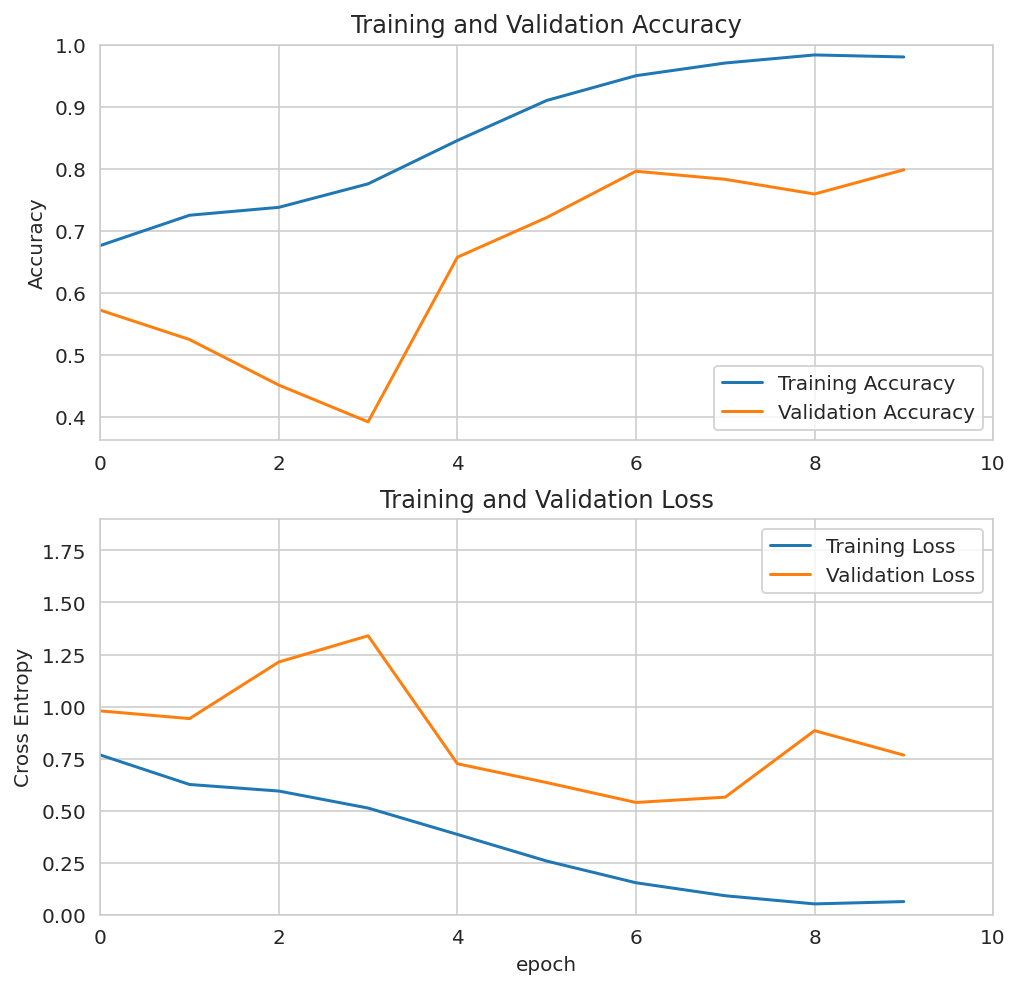

In [53]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.xlim([0,10])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.9])
plt.xlim([0,10])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

Evaluation metric results seem to show adding augmentation layers seem to make model learn faster. Therefore, will try augmented model with SGD Optimiser to see if learning pattern can be improved.

## Try with SGD Optimiser, if get better performance
using augmented model

In [ ]:
model.compile(optimizer='SGD', 
              loss="categorical_crossentropy", # match label_mode='categorical'
              metrics=['accuracy','AUC'])

# Train the model, doing validation at the end of each epoch.
epochs = 5

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("drive/MyDrive/Colab Notebooks/UNet_sgd_ep{epoch}_val{val_loss:.3f}", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=3,min_delta=0.001,restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('drive/MyDrive/Colab Notebooks/history_sgd.csv') # save history
]

history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/5
106/106 [==============================] - 1123s 11s/step - loss: 0.1854 - accuracy: 0.9283 - auc: 0.9939 - val_loss: 0.5780 - val_accuracy: 0.7568 - val_auc: 0.9425
Epoch 2/5
106/106 [==============================] - 1130s 11s/step - loss: 0.1564 - accuracy: 0.9440 - auc: 0.9954 - val_loss: 0.5385 - val_accuracy: 0.8043 - val_auc: 0.9607
Epoch 3/5
106/106 [==============================] - 1154s 11s/step - loss: 0.1449 - accuracy: 0.9484 - auc: 0.9958 - val_loss: 0.5027 - val_accuracy: 0.8268 - val_auc: 0.9638
Epoch 4/5
106/106 [==============================] - 1114s 11s/step - loss: 0.1321 - accuracy: 0.9526 - auc: 0.9964 - val_loss: 0.5302 - val_accuracy: 0.8244 - val_auc: 0.9629
Epoch 5/5
 88/106 [=======================>......] - ETA: 3:03 - loss: 0.1224 - accuracy: 0.9588 - auc: 0.9970

Preliminary metrics seem to show that with SGD optimizer, the model is learning better and faster.

## Evaluation

__References:__
1. [images](https://machinelearningmastery.com/image-augmentation-with-keras-preprocessing-layers-and-tf-image/)
1. [kaggle code](https://www.kaggle.com/code/gpiosenka/eye-disease-f1-score-92-6/notebook)